### **Praktikum 13 | ML Senin Pagi**

Nama : Rika Rahma

NIM : 0110222134

Rombel : TI08 - 2022

1. Import Library

In [57]:
# Import Library
import pandas as pd
import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

2. Load Dataset

In [58]:
!pip install kaggle

In [59]:
kaggle = '/content/kaggle.json'

In [60]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [61]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
handwritten-digits-0-9.zip: Skipping, found more recently modified local copy (use --force to force download)


In [62]:
from zipfile import ZipFile
import os

file_name = 'handwritten-digits-0-9.zip'

extract_folder = "dataset"
os.makedirs(extract_folder, exist_ok= True)

with ZipFile(file_name, 'r') as zip:
    zip.extractall(extract_folder)
    print('Done')

Done


In [63]:
data_0 = os.listdir('/content/dataset/0')
data_1 = os.listdir('/content/dataset/1')
data_2 = os.listdir('/content/dataset/2')
data_3 = os.listdir('/content/dataset/3')
data_4 = os.listdir('/content/dataset/4')
data_5 = os.listdir('/content/dataset/5')
data_6 = os.listdir('/content/dataset/6')
data_7 = os.listdir('/content/dataset/7')
data_8 = os.listdir('/content/dataset/8')
data_9 = os.listdir('/content/dataset/9')

In [64]:
len(data_0)

2236

3. Load dataset (Gambar => Numerik)

In [65]:
# Path dataset
base_path = '/content/dataset'  # Folder setelah extract

# Inisialisasi list
images = []
labels = []

In [66]:
# Loop load gambar dari folder 0-9
for digit in range(10):
    folder_path = os.path.join(base_path, str(digit))
    if os.path.exists(folder_path):
        file_list = os.listdir(folder_path)
        print(f"Folder {digit}: {len(file_list)} gambar")
        for file_name in file_list:
            img_path = os.path.join(folder_path, file_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, (28, 28))  # Pastikan 28x28
                # Invert jika background hitam (umum di dataset ini)
                if np.mean(img) > 127:  # Jika rata-rata pixel >127, kemungkinan inverted
                    img = 255 - img
                images.append(img)
                labels.append(digit)

Folder 0: 2236 gambar
Folder 1: 2241 gambar
Folder 2: 2233 gambar
Folder 3: 2202 gambar
Folder 4: 2179 gambar
Folder 5: 2126 gambar
Folder 6: 2121 gambar
Folder 7: 2116 gambar
Folder 8: 2085 gambar
Folder 9: 2016 gambar


In [67]:
# Konversi ke array
X = np.array(images)
y = np.array(labels)

print(f"Total data: {X.shape[0]} gambar, shape: {X.shape}")

Total data: 21555 gambar, shape: (21555, 28, 28)


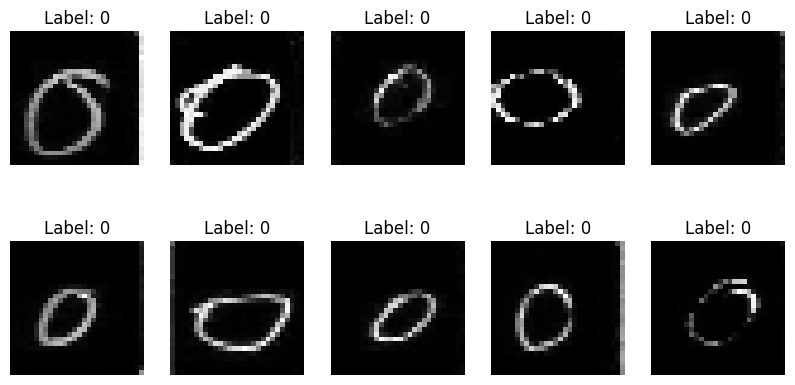

In [68]:
# Visualisasi 10 contoh gambar untuk cek data
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X[i], cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.show()

4. Preprocessing Data Citra MNIST

In [69]:
# Flatten dan normalisasi
X = X.reshape((X.shape[0], 28, 28, 1)).astype('float32') / 255.0  # Keep 4D untuk augmentation

# One-hot encoding
y_cat = to_categorical(y, 10)

In [70]:
# Split train-test
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42, stratify=y)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (17244, 28, 28, 1), Test shape: (4311, 28, 28, 1)


In [71]:
# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    shear_range=0.1
)
datagen.fit(X_train)

5. Arsitektur Model MLP

In [72]:
model = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(1024, activation='relu'),
    Dropout(0.3),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

model.summary()

# Compile dengan optimizer adam (learning rate kecil untuk stabilitas)
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,462,538 (5.58 MB)

 Trainable params: 1,462,538 (5.58 MB)

 Non-trainable params: 0 (0.00 B)

6. Training dan Evaluasi Model

In [73]:
# Callback
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [74]:
# Training dengan augmentation
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


270/270 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.2202 - loss: 2.1450 - val_accuracy: 0.6138 - val_loss: 1.2449
Epoch 2/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.5110 - loss: 1.4825 - val_accuracy: 0.7852 - val_loss: 0.7062
Epoch 3/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.6468 - loss: 1.0905 - val_accuracy: 0.8383 - val_loss: 0.5081
Epoch 4/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.7054 - loss: 0.9183 - val_accuracy: 0.8645 - val_loss: 0.4215
Epoch 5/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.7399 - loss: 0.8086 - val_accuracy: 0.8859 - val_loss: 0.3546
Epoch 6/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 13s 48ms/step - accuracy: 0.7593 - loss: 0.7545 - val_accuracy: 0.9040 - val_loss: 0.3187
Epoch 7/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 22s 81ms/step - accuracy: 0.7776 - loss: 0.6758 - val_accuracy: 0.9107 - val_loss: 0.2848
Epoch 8/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.7911 - loss: 0.6454 - val_accurac

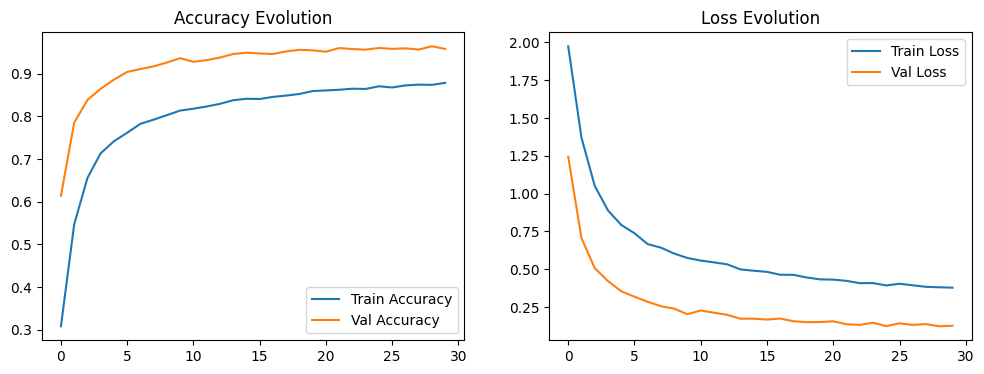

In [75]:
# Plot history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Evolution')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.legend()
plt.show()

7. Hasil Evaluasi Model (Akurasi, Loss, Confusion Matrix) dan Analisis Performa Model MLP pada Klasifikasi Multi-Kelas

In [76]:
# Evaluasi
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {test_acc:.4f}')
print(f'Test Loss: {test_loss:.4f}')

Test Accuracy: 0.9640
Test Loss: 0.1230


In [77]:
# Prediksi
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


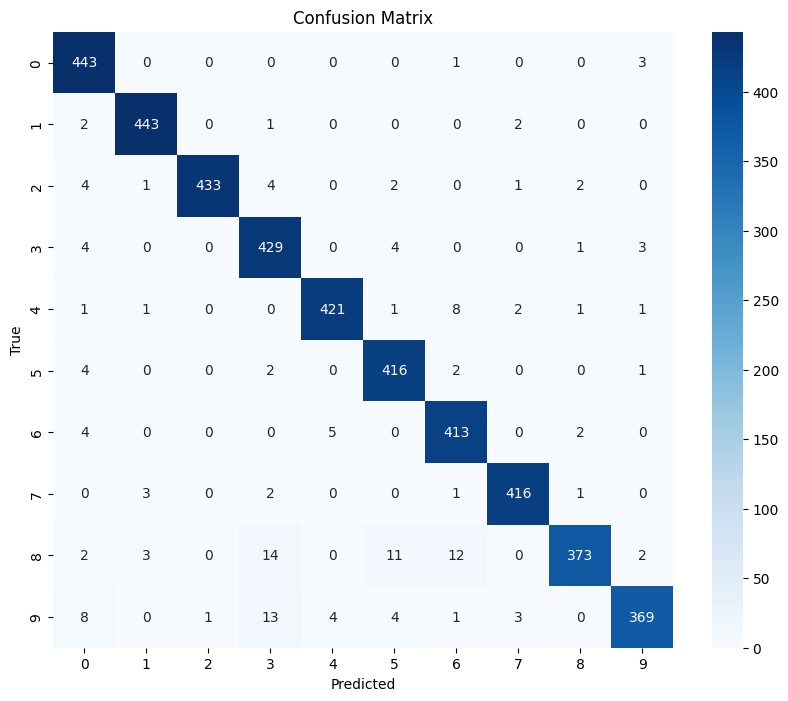

              precision    recall  f1-score   support

           0       0.94      0.99      0.96       447
           1       0.98      0.99      0.99       448
           2       1.00      0.97      0.98       447
           3       0.92      0.97      0.95       441
           4       0.98      0.97      0.97       436
           5       0.95      0.98      0.96       425
           6       0.94      0.97      0.96       424
           7       0.98      0.98      0.98       423
           8       0.98      0.89      0.94       417
           9       0.97      0.92      0.94       403

    accuracy                           0.96      4311
   macro avg       0.96      0.96      0.96      4311
weighted avg       0.96      0.96      0.96      4311



In [78]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Classification Report
print(classification_report(y_true, y_pred))